<a href="https://colab.research.google.com/github/Anuska111/SCFP2019-/blob/main/SCFP2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans
import plotly.express as px
from scipy.stats.mstats import trimmed_var
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("/content/SCFP2019 (2).csv")

In [3]:
df.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,6119.779308,2,75,6,12,4,2,0,...,5.0,3.0,6.0,3.0,2.0,10.0,6.0,6.0,3.0,3.0
1,1,12,4712.374912,2,75,6,12,4,2,0,...,5.0,3.0,6.0,3.0,1.0,10.0,5.0,5.0,2.0,2.0
2,1,13,5145.224455,2,75,6,12,4,2,0,...,5.0,3.0,6.0,3.0,1.0,10.0,5.0,5.0,2.0,2.0
3,1,14,5297.663412,2,75,6,12,4,2,0,...,5.0,2.0,6.0,2.0,1.0,10.0,4.0,4.0,2.0,2.0
4,1,15,4761.812371,2,75,6,12,4,2,0,...,5.0,3.0,6.0,3.0,1.0,10.0,5.0,5.0,2.0,2.0


In [5]:
features=["AGE","INCCAT","NWCAT","ASSETCAT"]
X=df[features]
X=X.dropna()
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
print("KMeans Model Definition and Attributes:")
print(f"Number of clusters: {kmeans.n_clusters}")
print("Cluster centers:\n", kmeans.cluster_centers_)
print(f"Model inertia: {kmeans.inertia_}")

KMeans Model Definition and Attributes:
Number of clusters: 3
Cluster centers:
 [[ 0.75135848 -0.66780875 -0.24347717 -0.33909984]
 [-1.02115232 -0.62759676 -0.99439679 -0.941937  ]
 [ 0.33113193  1.01419082  1.02229503  1.0462077 ]]
Model inertia: 4350.155573137809


In [7]:
age_groups=df["AGECL"].unique()
print("Age Groups:",age_groups)

Age Groups: [6 3 1 5 4 2]


In [9]:
agecl_dict={
    1:"Under 35",
    2:"35-44",
    3:"45-54",
    4:"55-64",
    5:"65-74",
    6:"75 or Older"
}
age_cl=df["AGECL"].replace(agecl_dict)
age_cl.head(10)

,AGECL
0,75 or Older
1,75 or Older
2,75 or Older
3,75 or Older
4,75 or Older
5,45-54
6,45-54
7,45-54
8,45-54
9,45-54


<Axes: xlabel='AGECL'>

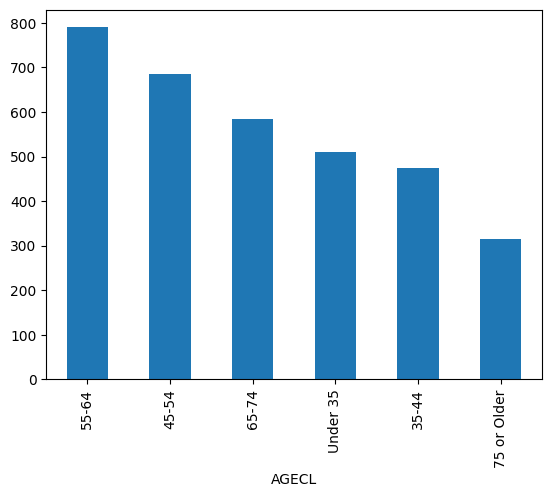

In [10]:
age_cl_value_counts=age_cl.value_counts()
age_cl_value_counts.plot(kind='bar')

<Axes: >

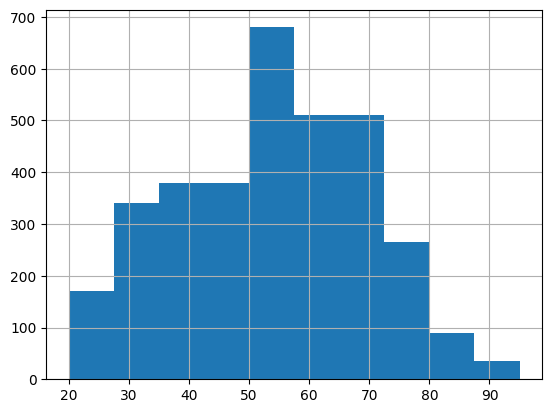

In [12]:
df["AGE"].hist(bins=10)

In [14]:
inccat_dict={
    1:"0-20",
    2:"20-39.9",
    3:"40-59.9",
    4:"60-79.9",
    5:"80-89.9",
    6:"90-100"
}
inccat=df["INCCAT"].replace(inccat_dict)
inccat.head(10)

,INCCAT
0,40-59.9
1,40-59.9
2,40-59.9
3,20-39.9
4,40-59.9
5,20-39.9
6,20-39.9
7,20-39.9
8,20-39.9
9,20-39.9


<Axes: xlabel='INCCAT'>

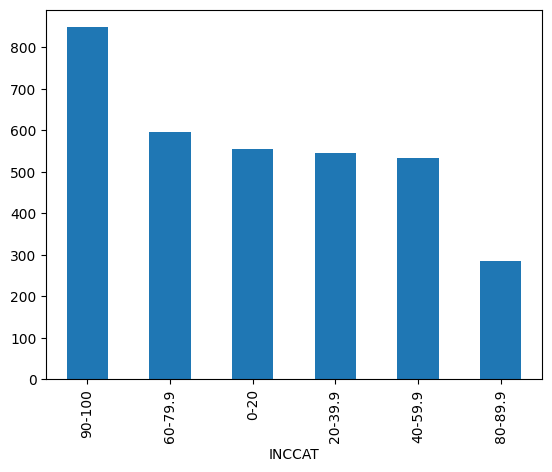

In [15]:
inccat_val_counts=inccat.value_counts()
inccat_val_counts.plot(kind='bar')

In [16]:
columns=["ASSET","HOUSES","INCOME","DEBT","EDUC"]
corr=df[columns].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.708778,0.888100,0.280806,0.115105
HOUSES,0.708778,1.000000,0.744887,0.445659,0.144879
INCOME,0.888100,0.744887,1.000000,0.117147,0.117638
DEBT,0.280806,0.445659,0.117147,1.000000,0.178592
EDUC,0.115105,0.144879,0.117638,0.178592,1.000000


In [18]:
corr_fear=df[columns].corr()
corr_fear.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.708778,0.888100,0.280806,0.115105
HOUSES,0.708778,1.000000,0.744887,0.445659,0.144879
INCOME,0.888100,0.744887,1.000000,0.117147,0.117638
DEBT,0.280806,0.445659,0.117147,1.000000,0.178592
EDUC,0.115105,0.144879,0.117638,0.178592,1.000000


<Figure size 1200x600 with 0 Axes>

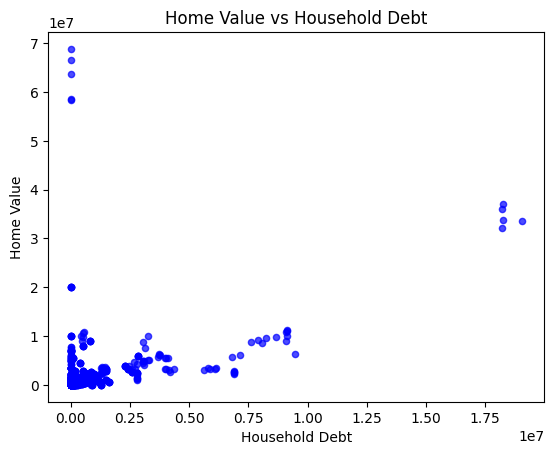

In [20]:
plt.figure(figsize=(12,6))
df.plot.scatter(x='DEBT',y="HOUSES",c='blue',alpha=0.7,marker='o')
plt.xlabel('Household Debt')
plt.ylabel('Home Value')
plt.title('Home Value vs Household Debt')
plt.show()

In [21]:
df["TURNFEAR"].value_counts()

,count
TURNFEAR,
0.0,2779
1.0,580


In [22]:
features=["AGE","INCCAT","NWCAT","ASSETCAT"]
X=df[features]
X=X.dropna()

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

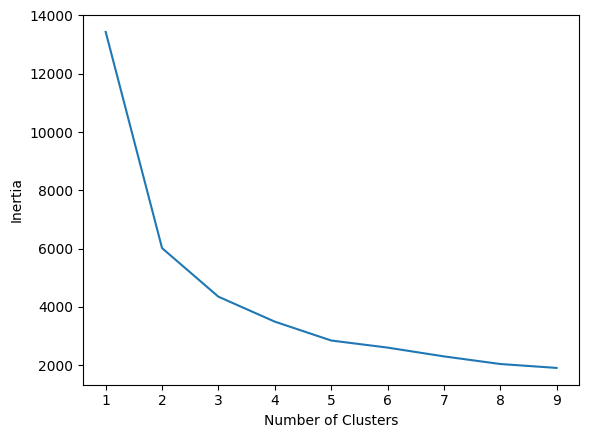

In [24]:
inertia=[]
for k in range (1,10):
   model=KMeans(n_clusters=k,random_state=42)
   model.fit(X_scaled)
   inertia.append(model.inertia_)

plt.plot(range(1,10),inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [25]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(X_scaled)

clusters=kmeans.labels_
X["Clusters"]=clusters
X.groupby("Clusters").mean()

,AGE,INCCAT,NWCAT,ASSETCAT
Clusters,,,,
0,65.497868,2.411514,2.717484,3.020256
1,37.286355,2.483842,1.579892,1.891382
2,58.809487,5.436878,4.635042,5.614384


In [26]:
labels = kmeans.labels_
labels[:10]

array([2, 2, 2, 2, 2, 1, 1, 1, 1, 1], dtype=int32)

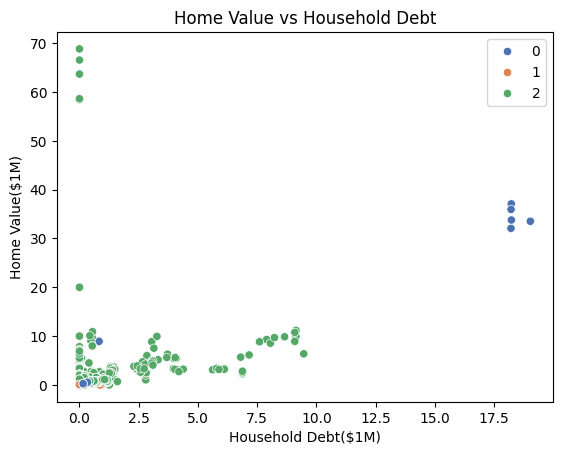

In [28]:
sns.scatterplot(
    x=df.loc[X.index, "DEBT"]/1e6,
    y=df.loc[X.index, "HOUSES"]/1e6,
    hue=labels,
    palette="deep"
)
plt.xlabel("Household Debt($1M)")
plt.ylabel("Home Value($1M)")
plt.title("Home Value vs Household Debt")
plt.show()